# Training Delivery Delay Predictor

## Imports

In [63]:
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV

import scipy.stats as stats

import xgboost as xgb

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

## Loding Data

In [35]:
data_path= '../data/processed/delivery_training_data.csv'
df= pd.read_csv(filepath_or_buffer= data_path)

In [36]:
df.head()

,order_id,purchase_month,purchase_day_of_week,estimated_days_to_deliver,is_delayed,total_freight_value,total_weight_g,total_volume_cm3,is_interstate,seller_historical_delay_rate
0,00010242fe8c5a6d1ba2dd792cb16214,9,4,16,0,13.29,650.0,3528.0,1,0.0680
1,00018f77f2f0320c557190d7a144bdd3,4,4,19,0,19.93,30000.0,60000.0,0,0.1479
2,000229ec398224ef6ca0657da4fc703e,1,1,22,0,17.87,3050.0,14157.0,0,0.0000
3,00024acbcdf0a6daa1e931b038114c75,8,4,12,0,12.79,200.0,2400.0,0,0.0625
4,00042b26cf59d7ce69dfabb4e55b4fd9,2,7,41,0,18.14,3750.0,42000.0,1,0.0741


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96986 entries, 0 to 96985
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   order_id                      96986 non-null  object 
 1   purchase_month                96986 non-null  int64  
 2   purchase_day_of_week          96986 non-null  int64  
 3   estimated_days_to_deliver     96986 non-null  int64  
 4   is_delayed                    96986 non-null  int64  
 5   total_freight_value           96986 non-null  float64
 6   total_weight_g                96970 non-null  float64
 7   total_volume_cm3              96970 non-null  float64
 8   is_interstate                 96986 non-null  int64  
 9   seller_historical_delay_rate  96986 non-null  float64
dtypes: float64(4), int64(5), object(1)
memory usage: 7.4+ MB


In [38]:
df.describe()

,purchase_month,purchase_day_of_week,estimated_days_to_deliver,is_delayed,total_freight_value,total_weight_g,total_volume_cm3,is_interstate,seller_historical_delay_rate
count,96986.000000,96986.000000,96986.000000,96986.000000,96986.000000,96970.000000,9.697000e+04,96986.000000,96986.000000
mean,6.031912,3.912431,24.391005,0.080733,22.664569,2374.167227,1.723971e+04,0.640958,0.079019
std,3.227971,1.895239,8.754967,0.272427,21.435324,4753.040835,3.003597e+04,0.479722,0.063802
min,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,1.680000e+02,0.000000,0.000000
25%,3.000000,2.000000,19.000000,0.000000,13.790000,300.000000,2.944000e+03,0.000000,0.046200
50%,6.000000,4.000000,24.000000,0.000000,17.140000,750.000000,7.200000e+03,1.000000,0.069000
75%,8.000000,6.000000,29.000000,0.000000,23.900000,2050.000000,1.980000e+04,1.000000,0.102500
max,12.000000,7.000000,156.000000,1.000000,1794.960000,184400.000000,1.476000e+06,1.000000,1.000000


In [39]:
df.shape

(96986, 10)

In [40]:
df.columns

Index(['order_id', 'purchase_month', 'purchase_day_of_week',
       'estimated_days_to_deliver', 'is_delayed', 'total_freight_value',
       'total_weight_g', 'total_volume_cm3', 'is_interstate',
       'seller_historical_delay_rate'],
      dtype='object')

In [41]:
df.dtypes

order_id                         object
purchase_month                    int64
purchase_day_of_week              int64
estimated_days_to_deliver         int64
is_delayed                        int64
total_freight_value             float64
total_weight_g                  float64
total_volume_cm3                float64
is_interstate                     int64
seller_historical_delay_rate    float64
dtype: object

## Train Test Split

In [43]:
# Dropping order_id
df= df.drop(columns= ['order_id'])

In [44]:
df.head()

,purchase_month,purchase_day_of_week,estimated_days_to_deliver,is_delayed,total_freight_value,total_weight_g,total_volume_cm3,is_interstate,seller_historical_delay_rate
0,9,4,16,0,13.29,650.0,3528.0,1,0.0680
1,4,4,19,0,19.93,30000.0,60000.0,0,0.1479
2,1,1,22,0,17.87,3050.0,14157.0,0,0.0000
3,8,4,12,0,12.79,200.0,2400.0,0,0.0625
4,2,7,41,0,18.14,3750.0,42000.0,1,0.0741


In [45]:
# Separating Features and Target Variable:
X = df.drop('is_delayed', axis= 1)
y= df['is_delayed']

In [46]:
X.head()

,purchase_month,purchase_day_of_week,estimated_days_to_deliver,total_freight_value,total_weight_g,total_volume_cm3,is_interstate,seller_historical_delay_rate
0,9,4,16,13.29,650.0,3528.0,1,0.0680
1,4,4,19,19.93,30000.0,60000.0,0,0.1479
2,1,1,22,17.87,3050.0,14157.0,0,0.0000
3,8,4,12,12.79,200.0,2400.0,0,0.0625
4,2,7,41,18.14,3750.0,42000.0,1,0.0741


In [47]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: is_delayed, dtype: int64

In [48]:
# Train Test Split:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2, random_state= 42)

In [49]:
print(f'Training Features Shape: {X_train.shape}')
print(f'Testing Features Shape: {X_test.shape}')

Training Features Shape: (77588, 8)
Testing Features Shape: (19398, 8)


## Data Pre-Processing Pipeline

In [50]:
X_train.head()

,purchase_month,purchase_day_of_week,estimated_days_to_deliver,total_freight_value,total_weight_g,total_volume_cm3,is_interstate,seller_historical_delay_rate
72686,6,3,21,14.00,1800.0,7616.0,0,0.0730
14966,5,3,13,11.90,4475.0,32736.0,0,0.0589
54119,11,2,31,38.10,6050.0,31920.0,1,0.0592
61611,7,6,21,27.47,2450.0,27000.0,1,0.0650
28377,4,3,17,8.88,600.0,5280.0,0,0.0474


In [51]:
X_train.dtypes

purchase_month                    int64
purchase_day_of_week              int64
estimated_days_to_deliver         int64
total_freight_value             float64
total_weight_g                  float64
total_volume_cm3                float64
is_interstate                     int64
seller_historical_delay_rate    float64
dtype: object

In [52]:
# Defining Feature Types:
numeric_features= ['estimated_days_to_deliver',
                   'total_freight_value',
                   'total_weight_g',
                   'total_volume_cm3',
                   'purchase_month',
                   'purchase_day_of_week',
                   'seller_historical_delay_rate']

binary_features= ['is_interstate']

In [53]:
# Pre-Processing Pipelines for Numeric Features and Binary Feature:
numeric_transformer= Pipeline(steps= [
    ('imputer', SimpleImputer(strategy= 'median')),
    ('scaler', RobustScaler()),
])

binary_transformer= Pipeline(steps= [
    ('imputer', SimpleImputer(strategy= 'most_frequent')),
])

In [54]:
# Pre-Processing Pipeline:
preprocessor= ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('bin', binary_transformer, binary_features)
    ]
)

## Model Training

In [55]:
# Calculating the ratio of negative (on-time) to positive (delayed) classes:
neg_class_count= (y_train == 0).sum()
pos_class_count= (y_train == 1).sum()
print(neg_class_count, pos_class_count)

71358 6230


In [56]:
# Scale Weight to Use in Model Training:
scale_weight= neg_class_count / pos_class_count
print(scale_weight)

11.453932584269664


In [57]:
# Initializing XGBoost Classifier:
xgb_model= xgb.XGBClassifier(
    scale_pos_weight= scale_weight,
    objective= 'binary:logistic',
    eval_metric= 'auc',
    random_state= 42,
    n_jobs= -1
)

In [58]:
# Final Pipeline with Data Pre-Processing and Model:
full_pipeline= Pipeline(steps= [
    ('preprocessor', preprocessor),
    ('classifier', xgb_model)
])

In [59]:
# Training The Model:
print('Training XGBoost Model...')
full_pipeline.fit(X_train, y_train)
print('Model Training Complete!')

Training XGBoost Model...
Model Training Complete!


## Model Evaluation

In [60]:
# Predictions on Test Data:
y_pred= full_pipeline.predict(X_test)

In [61]:
# Classification Report:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.79      0.87     17798
           1       0.22      0.65      0.32      1600

    accuracy                           0.78     19398
   macro avg       0.59      0.72      0.59     19398
weighted avg       0.90      0.78      0.82     19398



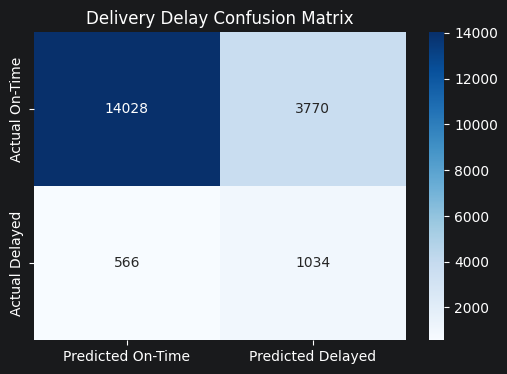

In [62]:
# Plotting Confusion Matrix:
cm= confusion_matrix(y_test, y_pred)
plt.figure(figsize= (6,4))
sns.heatmap(cm, annot= True, fmt= 'd', cmap= 'Blues',
            xticklabels= ['Predicted On-Time', 'Predicted Delayed'],
            yticklabels= ['Actual On-Time', 'Actual Delayed'])
plt.title('Delivery Delay Confusion Matrix')
plt.show()

## Hyper Parameter Tuning

In [64]:
# Parameter Dictionary:
# Because XGBoost is inside a Pipeline named 'classifier', we use the 'classifier__' prefix.
param_dist= {
    'classifier__max_depth': stats.randint(3, 10),
    'classifier__learning_rate': stats.uniform(0.01, 0.3),
    'classifier__subsample': stats.uniform(0.6, 0.4),
    'classifier__n_estimators': stats.randint(100, 500),
}

In [65]:
# Setting Up Randomized Search:
random_search= RandomizedSearchCV(
    estimator= full_pipeline,
    param_distributions= param_dist,
    n_iter= 20,
    scoring= 'f1',
    cv= 3,
    verbose= 2,
    n_jobs= -1,
    random_state= 42,
)